In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score

from utils import get_data

In [3]:
seed = 42
wine_X_tr, wine_X_val, wine_X_test, wine_y_tr, wine_y_val, wine_y_test = get_data(seed)

train_accs = []
test_accs = []
val_accs = []
depths = range(1, 30)

In [ ]:
for d in depths:
    rfc = RandomForestClassifier(max_depth=d, n_estimators=100, random_state=seed)
    rfc.fit(wine_X_tr, wine_y_tr)
    pred_tr = rfc.predict(wine_X_tr)
    pred_test = rfc.predict(wine_X_test)
    pred_val = rfc.predict(wine_X_val)

    train_error = 1 - accuracy_score(wine_y_tr, pred_tr)
    test_error = 1 - accuracy_score(wine_y_test, pred_test)
    val_error = 1 - accuracy_score(wine_y_val, pred_val)

    train_accs.append(1 - train_error)
    test_accs.append(1 - test_error)
    val_accs.append(1 - val_error)

print("Train Accuracies:", len(train_accs), train_accs)
print("Test Accuracies:", len(test_accs), test_accs)
print("Validation Accuracies:", len(val_accs), val_accs)

Train Accuracies: 29 [0.5173210161662818, 0.5316910443931229, 0.5563253784962792, 0.5699255837823967, 0.5984090325891711, 0.6399794713882474, 0.6836027713625866, 0.7321016166281755, 0.789838337182448, 0.8457788042083654, 0.8986399794713883, 0.941236848858096, 0.9725429817808571, 0.9910187323582242, 0.9964074929432897, 0.9987169617654607, 1.0, 0.9997433923530922, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
Test Accuracies: 29 [0.5153846153846153, 0.5161538461538462, 0.5407692307692308, 0.5446153846153846, 0.5623076923076923, 0.5723076923076923, 0.5907692307692308, 0.5938461538461538, 0.6061538461538462, 0.6061538461538462, 0.6223076923076923, 0.6261538461538462, 0.6446153846153846, 0.6330769230769231, 0.6415384615384615, 0.6423076923076924, 0.6315384615384615, 0.6423076923076924, 0.6369230769230769, 0.6415384615384615, 0.6369230769230769, 0.6361538461538462, 0.6423076923076924, 0.6330769230769231, 0.6376923076923077, 0.6415384615384615, 0.6392307692307693, 0.6361538461538462,

In [ ]:
# tree = rfc.estimators_[0]
# plt.figure(figsize=(300,250))
# plot_tree(tree, filled=True)
# plotting a tree was a bad idea...

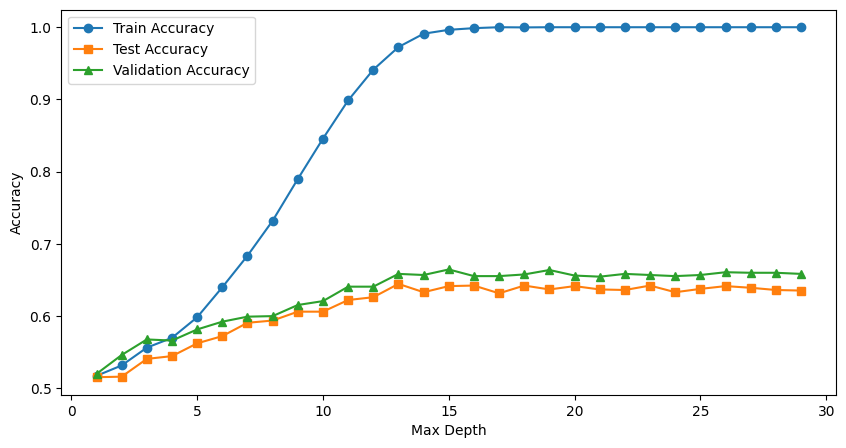

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(depths, train_accs, marker='o', label="Train Accuracy")
plt.plot(depths, test_accs, marker='s', label="Test Accuracy")
plt.plot(depths, val_accs, marker='^', label="Validation Accuracy")

plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.show()